# Random Forest — full evaluation pipeline

Mirrors `Gradient_Boosting.ipynb`: grouped train/test split, 5-fold GroupKFold CV, fairness/subgroups (AIF360), SHAP/LIME, and Excel export to `results/logs/random_forest_results.xlsx`.

**Models:** RADAR RFR, RADAR RFC, Androids RFC (no GPBoost analogue for RF).

Run all cells top to bottom.


In [1]:
from pathlib import Path
import sys
from datetime import datetime
import pandas as pd
import numpy as np
%pip install -q aif360 shap lime openpyxl
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric
from sklearn.model_selection import GroupKFold, GridSearchCV, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.stats import kruskal, wilcoxon

# Optional plain-text log (Excel export below is the main output for analysis).
SAVE_OUTPUT_LOG = False
OUTPUT_LOG_PATH = Path(
    "C:/Users/janku/Documents/KCL/Research Project/Research Project/results/logs/random_forest_run_log.txt"
)
EXCEL_EXPORT_PATH = Path(
    "C:/Users/janku/Documents/KCL/Research Project/Research Project/results/logs/random_forest_results.xlsx"
)

RESULTS_STORE = {
    "split_info": [],
    "best_params": [],
    "train_test_balance": [],
    "train_test_distribution": [],
    "cv_folds": [],
    "cv_balance": [],
    "statistical_tests": [],
    "cv_summary": [],
    "test_summary": [],
    "subgroup_gender": [],
    "subgroup_age": [],
    "subgroup_gender_age": [],
    "fairness": [],
    "wilcoxon": [],
    "confusion_matrices": [],
}

_OUTPUT_LOG_HANDLE = None
_ORIGINAL_STDOUT = sys.stdout
_ORIGINAL_STDERR = sys.stderr


class _TeeStream:
    def __init__(self, *streams):
        self.streams = streams

    def write(self, data):
        for stream in self.streams:
            stream.write(data)
            if hasattr(stream, "flush"):
                stream.flush()

    def flush(self):
        for stream in self.streams:
            if hasattr(stream, "flush"):
                stream.flush()

    def isatty(self):
        return self.streams[0].isatty() if self.streams else False


def setup_output_log(path=OUTPUT_LOG_PATH, enabled=SAVE_OUTPUT_LOG):
    """Mirror all stdout/stderr to a single text log file for this notebook run."""
    global _OUTPUT_LOG_HANDLE
    if not enabled:
        return
    if getattr(sys, "_notebook_log_enabled", False):
        return

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    _OUTPUT_LOG_HANDLE = open(path, "w", encoding="utf-8")
    _OUTPUT_LOG_HANDLE.write(
        f"Random Forest notebook run log\nStarted: {datetime.now()}\n\n"
    )
    _OUTPUT_LOG_HANDLE.flush()

    sys.stdout = _TeeStream(_ORIGINAL_STDOUT, _OUTPUT_LOG_HANDLE)
    sys.stderr = _TeeStream(_ORIGINAL_STDERR, _OUTPUT_LOG_HANDLE)
    sys._notebook_log_enabled = True
    sys._notebook_log_path = path
    print(f"Saving full notebook output to: {path}")


def finalize_output_log():
    """Restore normal printing and close the run log file."""
    global _OUTPUT_LOG_HANDLE
    if not getattr(sys, "_notebook_log_enabled", False):
        print("Output logging is not enabled.")
        return None

    log_path = Path(getattr(sys, "_notebook_log_path", OUTPUT_LOG_PATH))
    print(f"\nRun log saved to: {log_path.resolve()}")

    sys.stdout = _ORIGINAL_STDOUT
    sys.stderr = _ORIGINAL_STDERR
    sys._notebook_log_enabled = False

    if _OUTPUT_LOG_HANDLE is not None:
        _OUTPUT_LOG_HANDLE.write(f"\nEnded: {datetime.now()}\n")
        _OUTPUT_LOG_HANDLE.close()
        _OUTPUT_LOG_HANDLE = None

    return log_path


def ensure_output_log(path=OUTPUT_LOG_PATH, enabled=SAVE_OUTPUT_LOG):
    """Start combined logging if it is not already active."""
    if enabled and not getattr(sys, "_notebook_log_enabled", False):
        setup_output_log(path=path, enabled=enabled)


def log_model_section(model_name):
    """Mark the start of a model block in the notebook output."""
    ensure_output_log()
    print("\n" + "=" * 80)
    print(f"MODEL SECTION: {model_name}")
    print("=" * 80 + "\n")


def reset_results_store():
    """Clear Excel export buffers (call once before running model cells)."""
    for key in RESULTS_STORE:
        RESULTS_STORE[key] = []


def record_table(sheet_key, model_name, df):
    """Append a tidy table for later Excel export."""
    if df is None:
        return
    if isinstance(df, pd.Series):
        df = df.to_frame().T
    if len(df) == 0:
        return
    out = df.copy()
    if "model" not in out.columns:
        out.insert(0, "model", model_name)
    RESULTS_STORE.setdefault(sheet_key, []).append(out)


def record_confusion_matrix(model_name, cm, matrix_name):
    cm = np.asarray(cm)
    rows = []
    for i, true_lab in enumerate(["control_0", "depressed_1"]):
        for j, pred_lab in enumerate(["control_0", "depressed_1"]):
            rows.append({
                "model": model_name,
                "matrix": matrix_name,
                "true_label": true_lab,
                "pred_label": pred_lab,
                "count": int(cm[i, j]),
            })
    RESULTS_STORE.setdefault("confusion_matrices", []).append(pd.DataFrame(rows))


def record_standard_model_outputs(
    model_name,
    *,
    split_info=None,
    best_params=None,
    train_test_balance=None,
    train_test_distribution=None,
    cv_folds=None,
    cv_balance=None,
    statistical_tests=None,
    cv_summary=None,
    test_summary=None,
    wilcoxon=None,
    confusion_matrices=None,
):
    """Record all standard tabular outputs for one model."""
    if split_info is not None:
        record_table("split_info", model_name, pd.DataFrame([split_info]))
    if best_params is not None:
        record_table("best_params", model_name, pd.DataFrame([best_params]))
    if train_test_balance is not None:
        record_table("train_test_balance", model_name, train_test_balance)
    if train_test_distribution is not None:
        dist = train_test_distribution.reset_index().rename(columns={"index": "label"})
        record_table("train_test_distribution", model_name, dist)
    if cv_folds is not None:
        record_table("cv_folds", model_name, cv_folds)
    if cv_balance is not None:
        record_table("cv_balance", model_name, cv_balance.reset_index() if cv_balance.index.name else cv_balance)
    if statistical_tests is not None:
        record_table("statistical_tests", model_name, statistical_tests)
    if cv_summary is not None:
        record_table("cv_summary", model_name, cv_summary)
    if test_summary is not None:
        record_table("test_summary", model_name, test_summary)
    if wilcoxon is not None:
        for test_name, p_value in wilcoxon.items():
            record_table(
                "wilcoxon",
                model_name,
                pd.DataFrame([{"test_name": test_name, "p_value": p_value}]),
            )
    if confusion_matrices is not None:
        for matrix_name, cm in confusion_matrices.items():
            record_confusion_matrix(model_name, cm, matrix_name)


def export_results_to_excel(path=EXCEL_EXPORT_PATH):
    """Write all recorded tables to a multi-sheet Excel workbook."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        wrote_any = False
        for sheet_key, frames in RESULTS_STORE.items():
            if not frames:
                continue
            combined = pd.concat(frames, ignore_index=True)
            combined.to_excel(writer, sheet_name=sheet_key[:31], index=False)
            wrote_any = True
        if not wrote_any:
            pd.DataFrame(
                {"message": ["No results recorded. Run model cells, then export."]}
            ).to_excel(writer, sheet_name="info", index=False)

    print(f"\nExcel workbook saved to: {path.resolve()}")
    return path


def export_output_log_as_csv(
    log_path=OUTPUT_LOG_PATH,
    csv_path=None,
):
    """Optional: convert the text log into a one-column CSV."""
    log_path = Path(log_path)
    if csv_path is None:
        csv_path = log_path.with_suffix(".csv")
    else:
        csv_path = Path(csv_path)

    if not log_path.exists():
        raise FileNotFoundError(f"Log file not found: {log_path}")

    lines = log_path.read_text(encoding="utf-8").splitlines()
    pd.DataFrame({"output_line": lines}).to_csv(csv_path, index=False)
    return csv_path


def confusion_matrix_for_display(
    y_true,
    y_pred,
    title: str,
    labels=(0, 1),
) -> np.ndarray:
    """Compute confusion matrix and show heatmap in the notebook (no file I/O)."""
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["control (0)", "depressed (1)"],
    )
    disp.plot(ax=ax, colorbar=False, values_format="d")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()
    plt.close(fig)
    return cm


def _safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score, dtype=float)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def evaluate_by_group(y_true, y_pred, y_score, sensitive_feature):
    """Evaluate binary classification metrics within each subgroup."""
    eval_df = pd.DataFrame({
        "y_true": np.asarray(y_true).astype(int),
        "y_pred": np.asarray(y_pred).astype(int),
        "y_score": np.asarray(y_score, dtype=float),
        "group": pd.Series(sensitive_feature).reset_index(drop=True),
    }).dropna(subset=["group"])

    rows = []
    for group_value, group_df in eval_df.groupby("group", dropna=True):
        rows.append({
            "group": group_value,
            "n": len(group_df),
            "n_depressed": int(group_df["y_true"].sum()),
            "n_control": int((group_df["y_true"] == 0).sum()),
            "accuracy": accuracy_score(group_df["y_true"], group_df["y_pred"]),
            "f1": f1_score(group_df["y_true"], group_df["y_pred"], zero_division=0),
            "roc_auc": _safe_auc(group_df["y_true"], group_df["y_score"]),
        })

    return pd.DataFrame(rows)


def _gender_from_file_stem(file_stem):
    extracted = pd.Series(file_stem).astype(str).str.extract(r"^[0-9]+_[A-Z]?([FM])\d+", expand=False)
    return extracted.map({"F": "female", "M": "male"})


def _age_from_file_stem(file_stem):
    return pd.to_numeric(
        pd.Series(file_stem).astype(str).str.extract(r"^[0-9]+_[A-Z]?[FM](\d+)", expand=False),
        errors="coerce",
    )


def _format_gender(gender_values):
    gender = pd.Series(gender_values).reset_index(drop=True)
    if pd.api.types.is_numeric_dtype(gender):
        return "gender_" + gender.astype("Int64").astype(str)

    normalized = gender.astype(str).str.strip().str.lower()
    return normalized.replace({
        "f": "female",
        "female": "female",
        "woman": "female",
        "m": "male",
        "male": "male",
        "man": "male",
    })


def make_subgroup_frame(df_rows):
    """Return gender, age group, and intersection labels for held-out rows."""
    rows = df_rows.reset_index(drop=True)
    subgroup_df = pd.DataFrame(index=rows.index)

    if "Gender" in rows.columns:
        subgroup_df["gender"] = _format_gender(rows["Gender"])
    elif "gender" in rows.columns:
        subgroup_df["gender"] = _format_gender(rows["gender"])
    elif "file_stem" in rows.columns:
        subgroup_df["gender"] = _gender_from_file_stem(rows["file_stem"])

    if "Age" in rows.columns:
        age = pd.to_numeric(rows["Age"], errors="coerce")
    elif "age" in rows.columns:
        age = pd.to_numeric(rows["age"], errors="coerce")
    elif "file_stem" in rows.columns:
        age = _age_from_file_stem(rows["file_stem"])
    else:
        age = pd.Series(np.nan, index=rows.index)

    subgroup_df["age_group"] = pd.cut(
        age,
        bins=[-np.inf, 35, 55, np.inf],
        labels=["young", "middle", "older"],
    ).astype("object")

    if {"gender", "age_group"}.issubset(subgroup_df.columns):
        subgroup_df["gender_age_group"] = (
            subgroup_df["age_group"].astype(str) + " " + subgroup_df["gender"].astype(str)
        )
        subgroup_df.loc[
            subgroup_df["gender"].isna() | subgroup_df["age_group"].isna(),
            "gender_age_group",
        ] = np.nan

    return subgroup_df


def _gender_binary_code(df_rows):
    """Return 0/1 gender codes for AIF360 (0=unprivileged, 1=privileged)."""
    rows = df_rows.reset_index(drop=True)
    if "Gender" in rows.columns:
        return pd.to_numeric(rows["Gender"], errors="coerce")
    if "gender" in rows.columns:
        gender = _format_gender(rows["gender"])
    elif "file_stem" in rows.columns:
        gender = _gender_from_file_stem(rows["file_stem"])
    else:
        return pd.Series(np.nan, index=rows.index)
    return gender.map({"female": 0, "male": 1})


def print_aif360_fairness_metrics(model_name, y_pred, df_test_rows):
    """Print disparate impact and statistical parity on held-out predictions."""
    gender = _gender_binary_code(df_test_rows)
    valid = gender.notna()
    if valid.sum() < 2:
        print(f"\n{model_name} AIF360 fairness metrics: insufficient gender data")
        return

    y_pred_arr = np.asarray(y_pred, dtype=int).reshape(-1, 1)[valid.to_numpy()]
    gender_arr = gender[valid].astype(int).to_numpy()

    if len(np.unique(gender_arr)) < 2:
        print(f"\n{model_name} AIF360 fairness metrics: need both gender groups in test split")
        return

    fairness_df = pd.DataFrame({
        "gender": gender_arr,
        "depressed": y_pred_arr.ravel(),
        "dummy": 1,
    })

    dataset = BinaryLabelDataset(
        df=fairness_df,
        label_names=["depressed"],
        protected_attribute_names=["gender"],
        favorable_label=1,
        unfavorable_label=0,
    )

    metric = BinaryLabelDatasetMetric(
        dataset,
        privileged_groups=[{"gender": 1}],
        unprivileged_groups=[{"gender": 0}],
    )

    fairness_df = pd.DataFrame([{
        "disparate_impact": float(metric.disparate_impact()),
        "statistical_parity_difference": float(metric.statistical_parity_difference()),
    }])
    record_table("fairness", model_name, fairness_df)

    print(f"\n{model_name} AIF360 fairness metrics (held-out predictions):")
    print(f"  disparate_impact: {fairness_df['disparate_impact'].iloc[0]:.4f}")
    print(f"  statistical_parity_difference: {fairness_df['statistical_parity_difference'].iloc[0]:.4f}")


def print_subgroup_results(model_name, y_true, y_pred, y_score, subgroup_df, df_test_rows):
    sheet_map = {
        "gender": "subgroup_gender",
        "age_group": "subgroup_age",
        "gender_age_group": "subgroup_gender_age",
    }
    for column, label in [
        ("gender", "Gender"),
        ("age_group", "Age group"),
        ("gender_age_group", "Gender x age group"),
    ]:
        if column not in subgroup_df.columns:
            print(f"\n{model_name} {label} results: unavailable")
            continue
        results = evaluate_by_group(y_true, y_pred, y_score, subgroup_df[column])
        print(f"\n{model_name} {label} results:")
        print(results)
        record_table(sheet_map[column], model_name, results)

    print_aif360_fairness_metrics(model_name, y_pred, df_test_rows)


def _subsample_explanation_rows(X, max_rows=500, random_state=42):
    X = np.asarray(X, dtype=float)
    if len(X) <= max_rows:
        return X, np.arange(len(X))
    rng = np.random.default_rng(random_state)
    idx = rng.choice(len(X), size=max_rows, replace=False)
    return X[idx], idx




def run_shap_lime_explanations(
    model_name,
    model,
    X_train,
    X_test,
    feature_names,
    mode="classification",
    predict_fn=None,
    gpboost_reference=None,
    gpboost_groups=None,
    class_names=None,
    max_shap_samples=500,
    max_train_background=1000,
    n_lime_instances=2,
    num_lime_features=10,
):
    """Run SHAP summary plot and a few LIME explanations on held-out test rows."""
    import shap
    from lime.lime_tabular import LimeTabularExplainer

    X_train = np.asarray(X_train, dtype=float)
    X_test = np.asarray(X_test, dtype=float)
    feature_names = list(feature_names)

    if class_names is None:
        class_names = ["control", "depressed"] if mode == "classification" else ["target"]

    booster = model
    is_gpboost = gpboost_reference is not None and gpboost_groups is not None
    gpboost_groups_test = np.asarray(gpboost_groups) if is_gpboost else None

    if mode == "classification":
        if predict_fn is None and not is_gpboost:
            if model is None or not hasattr(model, "predict_proba"):
                print(f"\n{model_name} SHAP/LIME skipped: no classifier predict_proba available")
                return
            lime_predict_fn = model.predict_proba
        else:
            lime_predict_fn = predict_fn
    else:
        lime_predict_fn = predict_fn if predict_fn is not None else model.predict

    X_train_bg, _ = _subsample_explanation_rows(X_train, max_train_background)
    X_shap, shap_idx = _subsample_explanation_rows(X_test, max_shap_samples)
    if is_gpboost:
        predict_fn = make_gpboost_predict_fn(
            booster,
            X_shap,
            gpboost_groups_test[shap_idx],
        )
        model = None
    X_shap_df = pd.DataFrame(X_shap, columns=feature_names)

    print(f"\n{model_name} SHAP summary (held-out test sample, n={len(X_shap)}):")
    try:
        if model is not None:
            explainer = shap.Explainer(model, X_train_bg)
            shap_values = explainer(X_shap)
        elif mode == "classification":
            def positive_class_score(X_matrix):
                proba = lime_predict_fn(X_matrix)
                proba = np.asarray(proba)
                return proba[:, 1] if proba.ndim == 2 else proba

            explainer = shap.Explainer(positive_class_score, X_train_bg)
            shap_values = explainer(X_shap)
        else:
            explainer = shap.Explainer(lime_predict_fn, X_train_bg)
            shap_values = explainer(X_shap)

        shap.summary_plot(shap_values, X_shap_df, show=False)
        plt.tight_layout()
        plt.show()
        plt.close("all")
    except Exception as exc:
        print(f"  SHAP failed: {exc}")

    print(f"\n{model_name} LIME explanations (first {n_lime_instances} held-out instances):")
    try:
        lime_explainer = LimeTabularExplainer(
            X_train_bg,
            feature_names=feature_names,
            class_names=class_names,
            mode=mode,
            discretize_continuous=True,
        )
        n_show = min(n_lime_instances, len(X_test))
        for i in range(n_show):
            print(f"  Instance {i}:")
            if booster is not None and gpboost_groups_test is not None:
                group_id = int(gpboost_groups_test[i])

                def instance_predict_fn(X_matrix, gid=group_id):
                    X_matrix = np.asarray(X_matrix, dtype=float)
                    pred = booster.predict(
                        data=X_matrix,
                        group_data_pred=np.full(len(X_matrix), gid, dtype=np.int32),
                        predict_var=False,
                    )
                    p = pred["response_mean"]
                    return np.column_stack([1 - p, p])

                lime_fn = instance_predict_fn
            else:
                lime_fn = lime_predict_fn

            explanation = lime_explainer.explain_instance(
                X_test[i],
                lime_fn,
                num_features=min(num_lime_features, len(feature_names)),
            )
            fig = explanation.as_pyplot_figure()
            plt.tight_layout()
            plt.show()
            plt.close(fig)
    except Exception as exc:
        print(f"  LIME failed: {exc}")


reset_results_store()
setup_output_log()



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


## RADAR Analysis


### Random Forest Regressor

- Predicts continuous PHQ-8 (`phq8_score`)
- Binary metrics via PHQ-8 ≥ 10 threshold on regressor output



MODEL SECTION: RADAR RFR

Train rows: 6570
Test rows: 1945
Train participants: 219
Test participants: 55

Train/Test PHQ-8 balance:
      comparison  train_n  test_n  train_mean_phq8  train_median_phq8  \
0  train_vs_test     6570    1945          9.28828                9.0   

   test_mean_phq8  test_median_phq8  kruskal_H       p_value  
0         8.19126               7.0  54.532593  1.528910e-13  
Best GBR params from GridSearchCV: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 500}
  Wilcoxon p (|y-ŷ| GBR vs |y-ȳ_train|) fold 1: 3.506060512918391e-10
  Wilcoxon p (|y-ŷ| GBR vs |y-ȳ_train|) fold 2: 0.0019787722741681554
  Wilcoxon p (|y-ŷ| GBR vs |y-ȳ_train|) fold 3: 0.48030270985272516
  Wilcoxon p (|y-ŷ| GBR vs |y-ȳ_train|) fold 4: 0.004039612665433368
  Wilcoxon p (|y-ŷ| GBR vs |y-ȳ_train|) fold 5: 1.515693296762464e-07

CV fold results:
   fold       mae      rmse        r2  accuracy        f1   roc_auc  \
0     1  5.483327  6.648526  0.03530

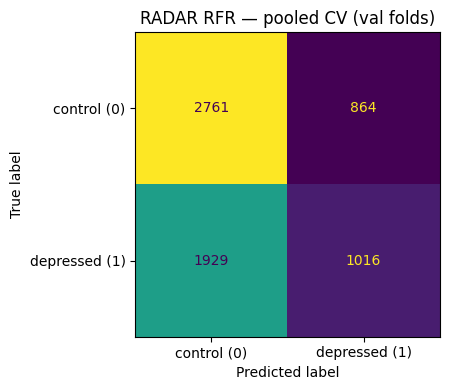

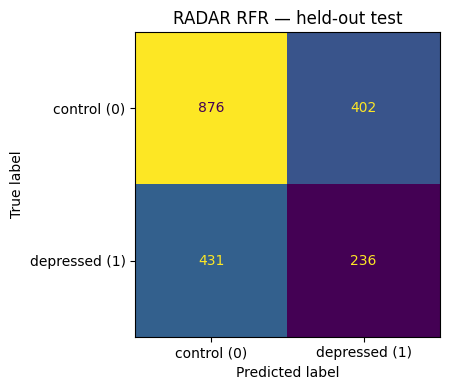


Pooled CV confusion matrix (PHQ-8 binarized):
 [[2761  864]
 [1929 1016]]

Held-out test confusion matrix:
 [[876 402]
 [431 236]]

RADAR RFR SHAP summary (held-out test sample, n=500):


 99%|===================| 496/500 [00:28<00:00]        

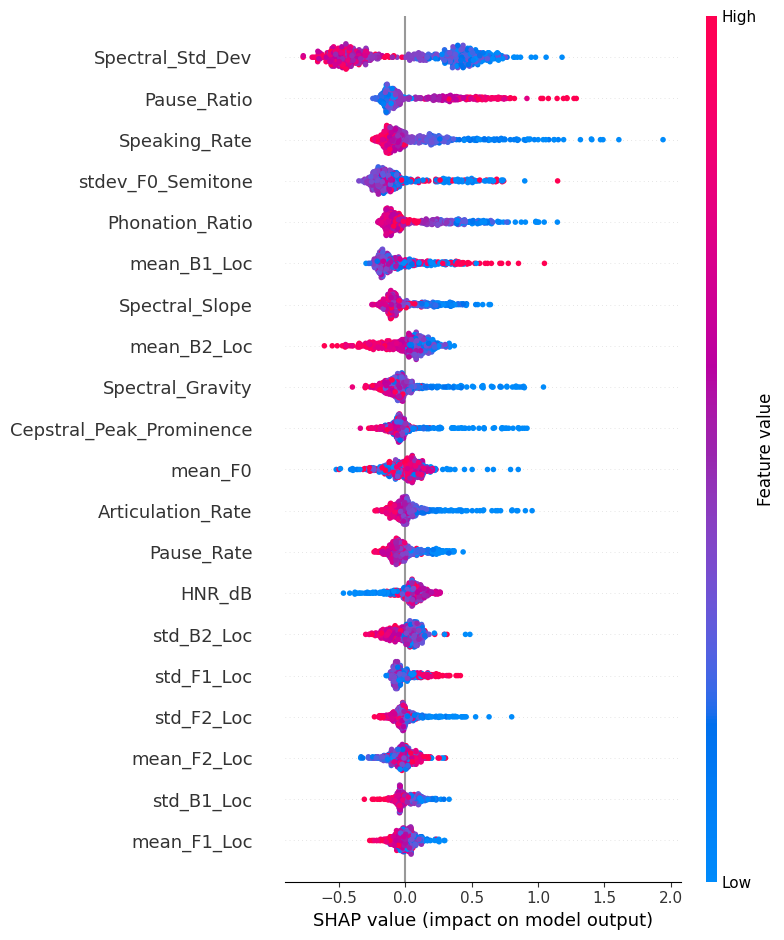


RADAR RFR LIME explanations (first 2 held-out instances):
  Instance 0:


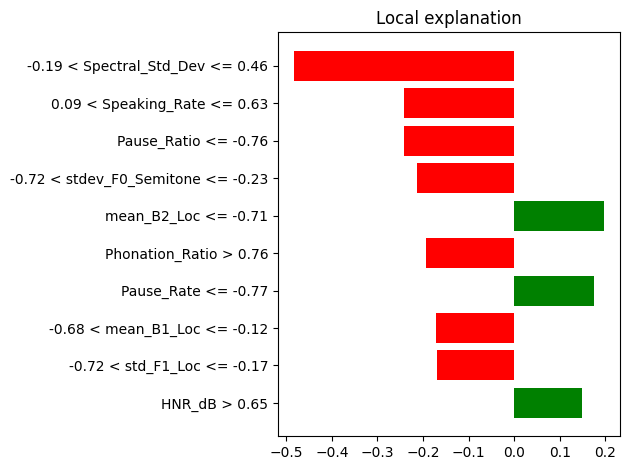

  Instance 1:


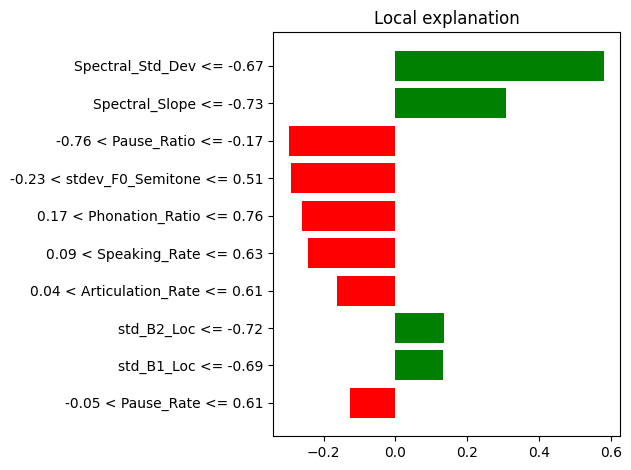

In [2]:

# -----------------------------
# Load and prepare data
# -----------------------------
log_model_section("RADAR RFR")

dataset = Path("C:/Users/janku/Documents/KCL/Research Project/Research Project/data/processed/radar_model_dataset_raw_features.csv")
df = pd.read_csv(dataset)

feature_cols = df.iloc[:, 12:-1].columns.tolist()
df = df.dropna(subset=feature_cols + ["phq8_score", "participant_id"]).copy()

# Binary label for classification-style metrics
df["depressed"] = (df["phq8_score"] >= 10).astype(int)

X = df[feature_cols].values
y = df["phq8_score"].values
y_bin = df["depressed"].values
groups = df["participant_id"].values

# -----------------------------
# Train / test split by participant
# -----------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train_full, X_test = X[train_idx], X[test_idx]
y_train_full, y_test = y[train_idx], y[test_idx]
y_bin_train_full, y_bin_test = y_bin[train_idx], y_bin[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test = scaler.transform(X_test)

print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))
print("Train participants:", len(np.unique(groups_train)))
print("Test participants:", len(np.unique(groups_test)))

# -----------------------------
# Statistical test: train vs test PHQ-8 balance
# -----------------------------
train_test_stat, train_test_p = kruskal(y_train_full, y_test)

train_test_balance_df = pd.DataFrame([{
    "comparison": "train_vs_test",
    "train_n": len(y_train_full),
    "test_n": len(y_test),
    "train_mean_phq8": np.mean(y_train_full),
    "train_median_phq8": np.median(y_train_full),
    "test_mean_phq8": np.mean(y_test),
    "test_median_phq8": np.median(y_test),
    "kruskal_H": train_test_stat,
    "p_value": train_test_p
}])

print("\nTrain/Test PHQ-8 balance:")
print(train_test_balance_df)

# -----------------------------
# Hyperparameter tuning on training set only
# -----------------------------
gkf = GroupKFold(n_splits=5)

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 10],
    "max_features": ["sqrt"],
    "min_samples_split": [2, 5],
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=gkf,
    n_jobs=-1
)
grid.fit(X_train_full, y_train_full, groups=groups_train)
best_rfr_params = grid.best_params_
print("Best GBR params from GridSearchCV:", best_rfr_params)

cv_results = []
cv_fold_phq8 = []
cv_y_true_bin, cv_y_pred_bin = [], []

for fold, (cv_train_idx, cv_val_idx) in enumerate(
    gkf.split(X_train_full, y_train_full, groups=groups_train), start=1
):
    X_train, X_val = X_train_full[cv_train_idx], X_train_full[cv_val_idx]
    y_train, y_val = y_train_full[cv_train_idx], y_train_full[cv_val_idx]
    y_bin_val = y_bin_train_full[cv_val_idx]

    cv_fold_phq8.append(y_val)

    model = RandomForestRegressor(
        **best_rfr_params,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    preds_bin = (preds >= 10).astype(int)
    cv_y_true_bin.extend(y_bin_val)
    cv_y_pred_bin.extend(preds_bin)

    # Paired Wilcoxon: |y - pred_RFR| vs |y - train-mean| (per-sample, same val rows)
    mean_train = float(np.mean(y_train))
    pred_mean = np.full_like(y_val, mean_train, dtype=float)
    e_gbr = np.abs(y_val - preds)
    e_base = np.abs(y_val - pred_mean)
    if len(e_gbr) >= 2 and not np.allclose(e_gbr, e_base):
        w_cv = float(wilcoxon(e_gbr, e_base, zero_method="wilcox", mode="auto").pvalue)
    else:
        w_cv = float("nan")
    print(f"  Wilcoxon p (|y-ŷ| GBR vs |y-ȳ_train|) fold {fold}:", w_cv)

    cv_results.append({
        "fold": fold,
        "mae": mean_absolute_error(y_val, preds),
        "rmse": np.sqrt(mean_squared_error(y_val, preds)),
        "r2": r2_score(y_val, preds),
        "accuracy": accuracy_score(y_bin_val, preds_bin),
        "f1": f1_score(y_bin_val, preds_bin),
        "roc_auc": roc_auc_score(y_bin_val, preds),
        "wilcoxon_p_vs_train_mean_baseline": w_cv
    })

cv_results_df = pd.DataFrame(cv_results)

print("\nCV fold results:")
print(cv_results_df)

# -----------------------------
# Statistical test: PHQ-8 balance across CV folds
# -----------------------------
cv_stat, cv_p = kruskal(*cv_fold_phq8)

cv_balance_rows = []
for i, vals in enumerate(cv_fold_phq8, start=1):
    cv_balance_rows.append({
        "fold": i,
        "n_rows": len(vals),
        "mean_phq8": np.mean(vals),
        "median_phq8": np.median(vals)
    })

cv_balance_df = pd.DataFrame(cv_balance_rows)
cv_balance_summary_df = pd.DataFrame([{
    "comparison": "cv_folds",
    "kruskal_H": cv_stat,
    "p_value": cv_p
}])

print("\nCV fold PHQ-8 balance:")
print(cv_balance_df)
print("\nCV fold Kruskal-Wallis test:")
print(cv_balance_summary_df)

cv_summary_df = pd.DataFrame([{
    "subset": "cv_train",
    "n_rows": len(train_idx),
    "n_depressed": int(y_bin_train_full.sum()),
    "n_control": int((y_bin_train_full == 0).sum()),
    "mae_mean": cv_results_df["mae"].mean(),
    "mae_std": cv_results_df["mae"].std(),
    "rmse_mean": cv_results_df["rmse"].mean(),
    "rmse_std": cv_results_df["rmse"].std(),
    "r2_mean": cv_results_df["r2"].mean(),
    "r2_std": cv_results_df["r2"].std(),
    "accuracy_mean": cv_results_df["accuracy"].mean(),
    "accuracy_std": cv_results_df["accuracy"].std(),
    "f1_mean": cv_results_df["f1"].mean(),
    "f1_std": cv_results_df["f1"].std(),
    "roc_auc_mean": cv_results_df["roc_auc"].mean(),
    "roc_auc_std": cv_results_df["roc_auc"].std(),
}])

print("\nCV summary:")
print(cv_summary_df)

# -----------------------------
# Final model: train on all training data, evaluate on held-out test set
# -----------------------------
final_model = RandomForestRegressor(
    **best_rfr_params,
    random_state=42
)

final_model.fit(X_train_full, y_train_full)
test_preds = final_model.predict(X_test)
test_preds_bin = (test_preds >= 10).astype(int)

test_summary_df = pd.DataFrame([{
    "subset": "held_out_test",
    "n_rows": len(test_idx),
    "n_depressed": int(y_bin_test.sum()),
    "n_control": int((y_bin_test == 0).sum()),
    "mae": mean_absolute_error(y_test, test_preds),
    "rmse": np.sqrt(mean_squared_error(y_test, test_preds)),
    "r2": r2_score(y_test, test_preds),
    "accuracy": accuracy_score(y_bin_test, test_preds_bin),
    "f1": f1_score(y_bin_test, test_preds_bin),
    "roc_auc": roc_auc_score(y_bin_test, test_preds)
}])

print("\nHeld-out test results:")
print(test_summary_df)

test_subgroups = make_subgroup_frame(df.iloc[test_idx])
print_subgroup_results(
    "RADAR RFR",
    y_bin_test,
    test_preds_bin,
    test_preds,
    test_subgroups,
    df.iloc[test_idx],
)

baseline_test = np.full_like(y_test, float(np.mean(y_train_full)), dtype=float)
e_gbr_t = np.abs(y_test - test_preds)
e_b_t = np.abs(y_test - baseline_test)
if len(e_gbr_t) >= 2 and not np.allclose(e_gbr_t, e_b_t):
    w_test = float(wilcoxon(e_gbr_t, e_b_t, zero_method="wilcox", mode="auto").pvalue)
else:
    w_test = float("nan")
print("\nWilcoxon p (held-out, paired |y-ŷ_RFR| vs |y-ȳ_train|):", w_test)
if w_test < 0.05:
    print("  Significant difference from train-mean baseline (alpha=0.05) on this test set.")
else:
    print("  No significant difference from train-mean baseline at alpha=0.05 (improvement may be chance on this split).")

# -----------------------------
# Confusion matrices (PHQ-8 >= 10 threshold on regressor output)
# -----------------------------
cm_cv = confusion_matrix_for_display(
    cv_y_true_bin,
    cv_y_pred_bin,
    title="RADAR RFR — pooled CV (val folds)",
)
cm_test = confusion_matrix_for_display(
    y_bin_test,
    test_preds_bin,
    title="RADAR RFR — held-out test",
)
print("\nPooled CV confusion matrix (PHQ-8 binarized):\n", cm_cv)
print("\nHeld-out test confusion matrix:\n", cm_test)

record_standard_model_outputs(
    "RADAR RFR",
    split_info={
        "train_rows": len(train_idx),
        "test_rows": len(test_idx),
        "train_participants": len(np.unique(groups_train)),
        "test_participants": len(np.unique(groups_test)),
    },
    best_params=best_rfr_params,
    train_test_balance=train_test_balance_df,
    cv_folds=cv_results_df,
    cv_balance=cv_balance_df,
    statistical_tests=cv_balance_summary_df,
    cv_summary=cv_summary_df,
    test_summary=test_summary_df,
    wilcoxon={"held_out_rfr_vs_train_mean": w_test},
    confusion_matrices={"cv_pooled": cm_cv, "held_out_test": cm_test},
)

run_shap_lime_explanations(
    "RADAR RFR",
    final_model,
    X_train_full,
    X_test,
    feature_cols,
    mode="regression",
    class_names=["phq8"],
)


### Random Forest Classifier

- Binary `depressed` label (PHQ-8 ≥ 10)



MODEL SECTION: RADAR RFC

Train rows: 6570
Test rows: 1945
Train participants: 219
Test participants: 55

Train/Test label distribution:
           train  test
control     3625  1278
depressed   2945   667

Train/Test Chi-square test:
      comparison  train_n  test_n  train_control  train_depressed  \
0  train_vs_test     6570    1945           3625             2945   

   test_control  test_depressed       chi2       p_value  
0          1278             667  67.720721  1.883734e-16  
Best GBC params from GridSearchCV: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 500}
  Wilcoxon p (|y - p_RFC| vs |y - p_dummy|) fold 1: 1.6719279132914132e-07
  Wilcoxon p (|y - p_RFC| vs |y - p_dummy|) fold 2: 0.03228009861461694
  Wilcoxon p (|y - p_RFC| vs |y - p_dummy|) fold 3: 0.3035929704298618
  Wilcoxon p (|y - p_RFC| vs |y - p_dummy|) fold 4: 0.002943850128178737
  Wilcoxon p (|y - p_RFC| vs |y - p_dummy|) fold 5: 0.00012301984158878703

CV fold results:
 

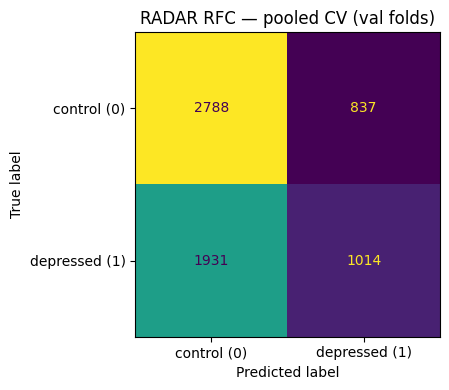

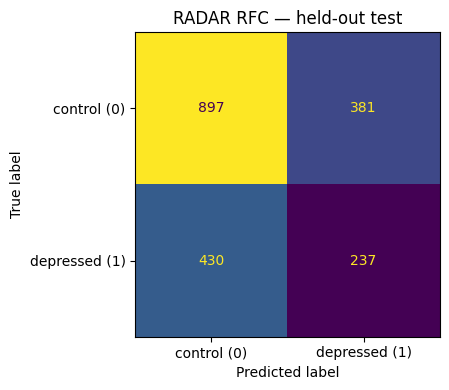


Pooled CV confusion matrix:
 [[2788  837]
 [1931 1014]]

Held-out test confusion matrix:
 [[897 381]
 [430 237]]

RADAR RFC SHAP summary (held-out test sample, n=500):


 98%|===================| 983/1000 [00:43<00:00]        

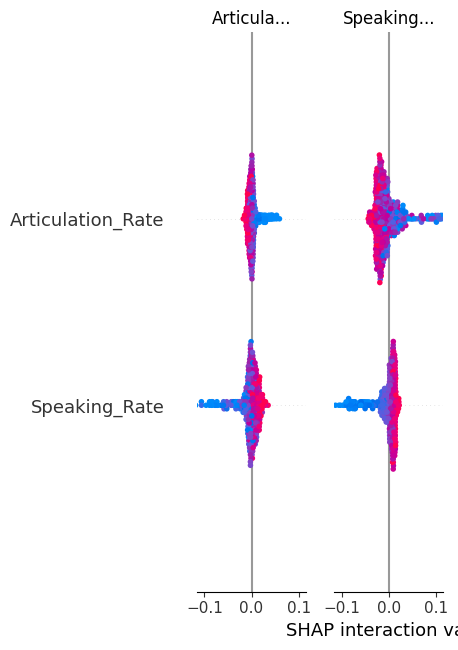


RADAR RFC LIME explanations (first 2 held-out instances):
  Instance 0:


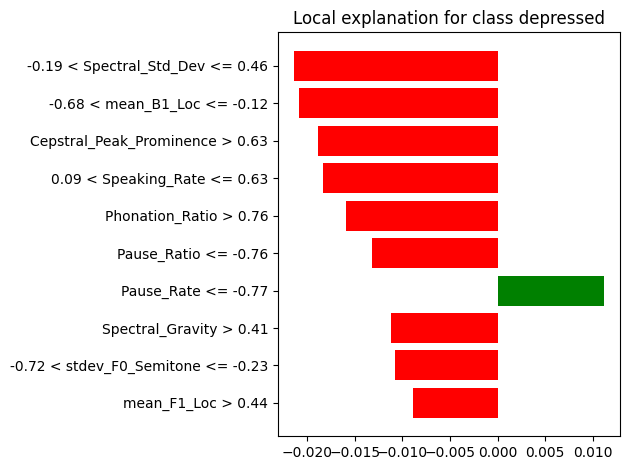

  Instance 1:


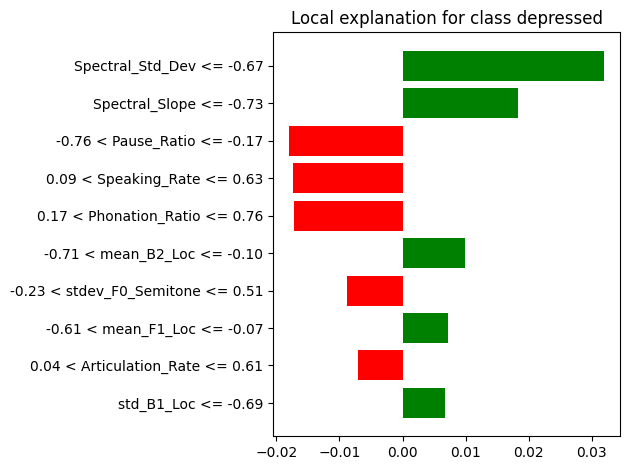

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

from scipy.stats import chi2_contingency, wilcoxon

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# -----------------------------
# Load and prepare data
# -----------------------------
log_model_section("RADAR RFC")

dataset = Path("C:/Users/janku/Documents/KCL/Research Project/Research Project/data/processed/radar_model_dataset_raw_features.csv")
df = pd.read_csv(dataset)

feature_cols = df.iloc[:, 12:-1].columns.tolist()
df = df.dropna(subset=feature_cols + ["phq8_score", "participant_id"]).copy()

# Binary target
df["depressed"] = (df["phq8_score"] >= 10).astype(int)

X = df[feature_cols].values
y_bin = df["depressed"].values
groups = df["participant_id"].values

# -----------------------------
# Held-out test split by participant
# -----------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y_bin, groups=groups))

X_train_full, X_test = X[train_idx], X[test_idx]
y_train_full, y_test = y_bin[train_idx], y_bin[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test = scaler.transform(X_test)

print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))
print("Train participants:", len(np.unique(groups_train)))
print("Test participants:", len(np.unique(groups_test)))

# -----------------------------
# Statistical test: train vs test label balance
# -----------------------------
train_test_table = pd.DataFrame({
    "train": pd.Series(y_train_full).value_counts().sort_index(),
    "test": pd.Series(y_test).value_counts().sort_index()
}).fillna(0)

train_test_table.index = ["control", "depressed"]

chi2_train_test, p_train_test, dof_train_test, expected_train_test = chi2_contingency(train_test_table.T)

train_test_balance_df = pd.DataFrame([{
    "comparison": "train_vs_test",
    "train_n": len(y_train_full),
    "test_n": len(y_test),
    "train_control": int((y_train_full == 0).sum()),
    "train_depressed": int((y_train_full == 1).sum()),
    "test_control": int((y_test == 0).sum()),
    "test_depressed": int((y_test == 1).sum()),
    "chi2": chi2_train_test,
    "p_value": p_train_test
}])

print("\nTrain/Test label distribution:")
print(train_test_table)
print("\nTrain/Test Chi-square test:")
print(train_test_balance_df)

# -----------------------------
# Hyperparameter tuning on training set only
# -----------------------------
gkf = GroupKFold(n_splits=5)

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 10],
    "max_features": ["sqrt"],
    "min_samples_split": [2, 5],
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=gkf,
    n_jobs=-1
)
grid.fit(X_train_full, y_train_full, groups=groups_train)
best_rfc_params = grid.best_params_
print("Best GBC params from GridSearchCV:", best_rfc_params)

cv_results = []
cv_fold_rows = []
cv_y_true, cv_y_pred = [], []

for fold, (cv_train_idx, cv_val_idx) in enumerate(
    gkf.split(X_train_full, y_train_full, groups=groups_train), start=1
):
    X_train, X_val = X_train_full[cv_train_idx], X_train_full[cv_val_idx]
    y_train, y_val = y_train_full[cv_train_idx], y_train_full[cv_val_idx]

    counts = pd.Series(y_val).value_counts().sort_index()
    cv_fold_rows.append({
        "fold": fold,
        "control": int(counts.get(0, 0)),
        "depressed": int(counts.get(1, 0)),
        "n_rows": len(y_val)
    })

    model = RandomForestClassifier(
        **best_rfc_params,
        random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    proba = model.predict_proba(X_val)[:, 1]
    cv_y_true.extend(y_val)
    cv_y_pred.extend(preds)

    # Paired Wilcoxon: |y - p_RFC| vs |y - p_stratified_dummy|
    dummy = DummyClassifier(strategy="stratified", random_state=42)
    dummy.fit(X_train, y_train)
    p_dum = dummy.predict_proba(X_val)[:, 1]
    e1 = np.abs(y_val - proba)
    e2 = np.abs(y_val - p_dum)
    if len(e1) >= 2 and not np.allclose(e1, e2):
        w_p = float(wilcoxon(e1, e2, zero_method="wilcox", mode="auto").pvalue)
    else:
        w_p = float("nan")
    print(f"  Wilcoxon p (|y - p_RFC| vs |y - p_dummy|) fold {fold}:", w_p)

    cv_results.append({
        "fold": fold,
        "accuracy": accuracy_score(y_val, preds),
        "f1": f1_score(y_val, preds),
        "roc_auc": roc_auc_score(y_val, proba),
        "wilcoxon_p_vs_stratified_dummy": w_p
    })

cv_results_df = pd.DataFrame(cv_results)

print("\nCV fold results:")
print(cv_results_df)

# -----------------------------
# Statistical test: label balance across CV folds
# -----------------------------
cv_balance_df = pd.DataFrame(cv_fold_rows).set_index("fold")
chi2_cv, p_cv, dof_cv, expected_cv = chi2_contingency(cv_balance_df[["control", "depressed"]])

cv_balance_summary_df = pd.DataFrame([{
    "comparison": "cv_folds",
    "chi2": chi2_cv,
    "p_value": p_cv
}])

print("\nCV fold label distribution:")
print(cv_balance_df)
print("\nCV fold Chi-square test:")
print(cv_balance_summary_df)

cv_summary_df = pd.DataFrame([{
    "subset": "cv_train",
    "n_rows": len(train_idx),
    "n_depressed": int(y_train_full.sum()),
    "n_control": int((y_train_full == 0).sum()),
    "accuracy_mean": cv_results_df["accuracy"].mean(),
    "accuracy_std": cv_results_df["accuracy"].std(),
    "f1_mean": cv_results_df["f1"].mean(),
    "f1_std": cv_results_df["f1"].std(),
    "roc_auc_mean": cv_results_df["roc_auc"].mean(),
    "roc_auc_std": cv_results_df["roc_auc"].std(),
}])

print("\nCV summary:")
print(cv_summary_df)

# -----------------------------
# Final model on full training set
# -----------------------------
final_model = RandomForestClassifier(
    **best_rfc_params,
    random_state=42
)

final_model.fit(X_train_full, y_train_full)

test_preds = final_model.predict(X_test)
test_proba = final_model.predict_proba(X_test)[:, 1]

test_summary_df = pd.DataFrame([{
    "subset": "held_out_test",
    "n_rows": len(test_idx),
    "n_depressed": int(y_test.sum()),
    "n_control": int((y_test == 0).sum()),
    "accuracy": accuracy_score(y_test, test_preds),
    "f1": f1_score(y_test, test_preds),
    "roc_auc": roc_auc_score(y_test, test_proba)
}])

print("\nHeld-out test results:")
print(test_summary_df)

test_subgroups = make_subgroup_frame(df.iloc[test_idx])
print_subgroup_results(
    "RADAR RFC",
    y_test,
    test_preds,
    test_proba,
    test_subgroups,
    df.iloc[test_idx],
)

dummy_t = DummyClassifier(strategy="stratified", random_state=42)
dummy_t.fit(X_train_full, y_train_full)
p_dum_t = dummy_t.predict_proba(X_test)[:, 1]
e_gb = np.abs(y_test - test_proba)
e_du = np.abs(y_test - p_dum_t)
if len(e_gb) >= 2 and not np.allclose(e_gb, e_du):
    w_held = float(wilcoxon(e_gb, e_du, zero_method="wilcox", mode="auto").pvalue)
else:
    w_held = float("nan")
print("\nWilcoxon p (held-out, |y - p_RFC| vs |y - p_dummy|):", w_held)
if w_held < 0.05:
    print("  Distributions of abs calibration errors differ from dummy (alpha=0.05).")
else:
    print("  No significant difference from stratified-dummy at alpha=0.05 on this test set (could be chance / split).")

# -----------------------------
# Confusion matrices
# -----------------------------
cm_cv = confusion_matrix_for_display(
    cv_y_true,
    cv_y_pred,
    title="RADAR RFC — pooled CV (val folds)",
)
cm_test = confusion_matrix_for_display(
    y_test,
    test_preds,
    title="RADAR RFC — held-out test",
)
print("\nPooled CV confusion matrix:\n", cm_cv)
print("\nHeld-out test confusion matrix:\n", cm_test)

record_standard_model_outputs(
    "RADAR RFC",
    split_info={
        "train_rows": len(train_idx),
        "test_rows": len(test_idx),
        "train_participants": len(np.unique(groups_train)),
        "test_participants": len(np.unique(groups_test)),
    },
    best_params=best_rfc_params,
    train_test_balance=train_test_balance_df,
    train_test_distribution=train_test_table,
    cv_folds=cv_results_df,
    cv_balance=cv_balance_df,
    statistical_tests=cv_balance_summary_df,
    cv_summary=cv_summary_df,
    test_summary=test_summary_df,
    wilcoxon={"held_out_rfc_vs_stratified_dummy": w_held},
    confusion_matrices={"cv_pooled": cm_cv, "held_out_test": cm_test},
)

run_shap_lime_explanations(
    "RADAR RFC",
    final_model,
    X_train_full,
    X_test,
    feature_cols,
    mode="classification",
)


## Androids Analysis



MODEL SECTION: Androids RFC

Best GBC params from GridSearchCV: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
  Wilcoxon p (|y - p_RFC| vs |y - p_dummy|) fold 1: 0.5296697249254814
  Wilcoxon p (|y - p_RFC| vs |y - p_dummy|) fold 2: 0.4795204631991451
  Wilcoxon p (|y - p_RFC| vs |y - p_dummy|) fold 3: 0.06372000731840326
  Wilcoxon p (|y - p_RFC| vs |y - p_dummy|) fold 4: 0.9624036060364755
  Wilcoxon p (|y - p_RFC| vs |y - p_dummy|) fold 5: 0.7806346055165158
CV fold results:
   fold  accuracy        f1   roc_auc  wilcoxon_p_vs_stratified_dummy
0     1  0.555556  0.555556  0.649351                        0.529670
1     2  0.722222  0.800000  0.887500                        0.479520
2     3  0.777778  0.777778  0.862500                        0.063720
3     4  0.638889  0.763636  0.638462                        0.962404
4     5  0.571429  0.651163  0.673203                        0.780635

CV summary:
     subset  n_rows  n_depressed  n_cont

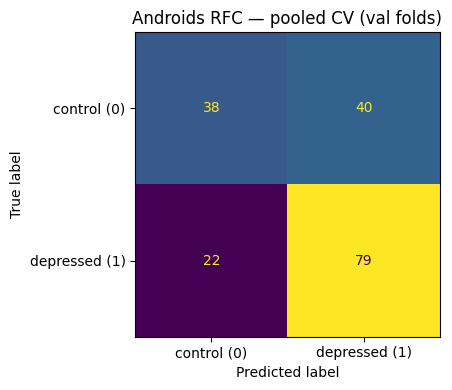

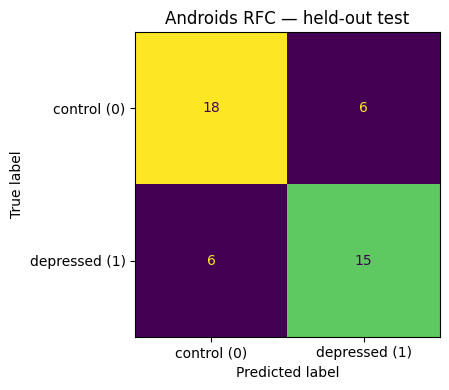


Pooled CV confusion matrix:
 [[38 40]
 [22 79]]

Held-out test confusion matrix:
 [[18  6]
 [ 6 15]]

Androids RFC SHAP summary (held-out test sample, n=45):


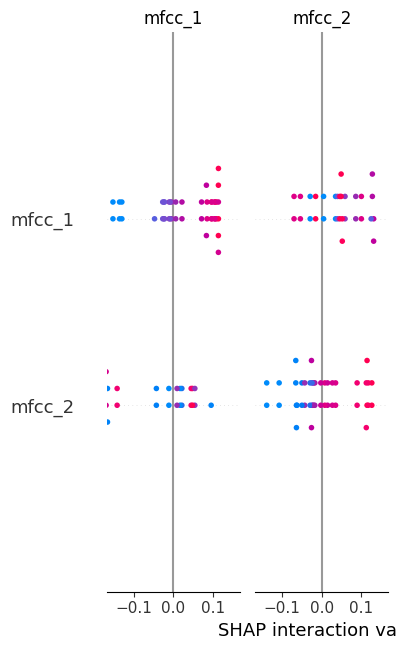


Androids RFC LIME explanations (first 2 held-out instances):
  Instance 0:


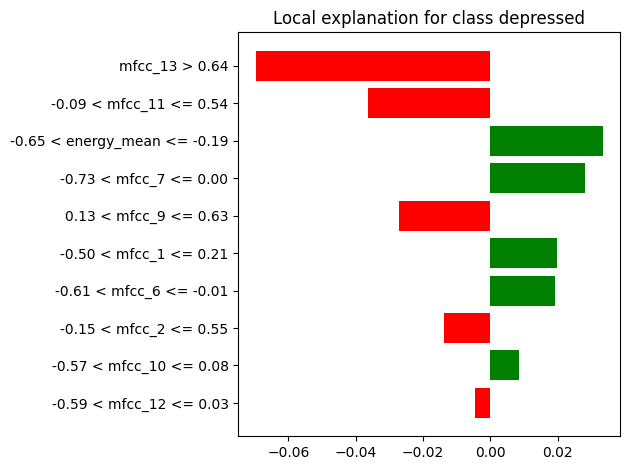

  Instance 1:


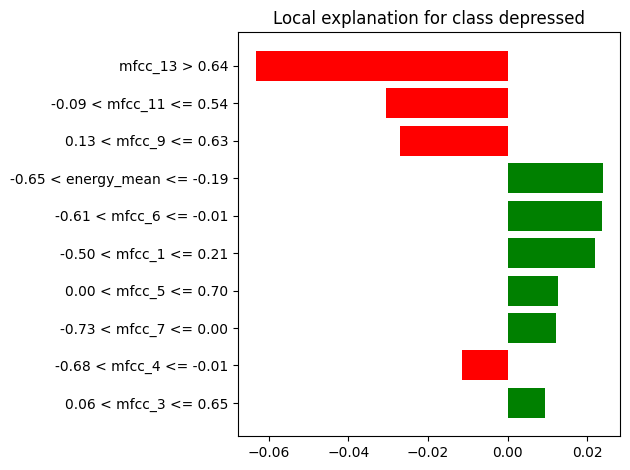

In [4]:
# Paths
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from scipy.stats import wilcoxon

dataset = Path("C:/Users/janku/Documents/KCL/Research Project/Research Project/data/processed/androids_model_dataset_basic.csv")
# Load
log_model_section("Androids RFC")

df = pd.read_csv(dataset)

meta_cols = [
    "file_path", "file", "file_stem", "bdi_score",
    "depressed", "fold", "speech_type", "subgroup_from_path"
]

feature_cols = [c for c in df.columns if c not in meta_cols]

df = df.dropna(subset=feature_cols + ["depressed", "file_stem"]).copy()

X = df[feature_cols].values
y = df["depressed"].astype(int).values
groups = df["file_stem"].values

# Train/test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train_full, X_test = X[train_idx], X[test_idx]
y_train_full, y_test = y[train_idx], y[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test = scaler.transform(X_test)

# Tune model on training set
param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 10],
    "max_features": ["sqrt"],
    "min_samples_split": [2, 5],
}

gkf = GroupKFold(n_splits=5)
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=gkf,
    n_jobs=-1
)
grid.fit(X_train_full, y_train_full, groups=groups_train)
best_rfc_params = grid.best_params_
print("Best GBC params from GridSearchCV:", best_rfc_params)

# CV on training set
cv_results = []
cv_y_true, cv_y_pred = [], []

for fold, (cv_train_idx, cv_val_idx) in enumerate(
    gkf.split(X_train_full, y_train_full, groups=groups_train), start=1
):
    X_train, X_val = X_train_full[cv_train_idx], X_train_full[cv_val_idx]
    y_train, y_val = y_train_full[cv_train_idx], y_train_full[cv_val_idx]

    model = RandomForestClassifier(
        **best_rfc_params,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    proba = model.predict_proba(X_val)[:, 1]
    cv_y_true.extend(y_val)
    cv_y_pred.extend(preds)

    dummy = DummyClassifier(strategy="stratified", random_state=42)
    dummy.fit(X_train, y_train)
    p_dum = dummy.predict_proba(X_val)[:, 1]
    e1 = np.abs(y_val - proba)
    e2 = np.abs(y_val - p_dum)
    if len(e1) >= 2 and not np.allclose(e1, e2):
        w_p = float(wilcoxon(e1, e2, zero_method="wilcox", mode="auto").pvalue)
    else:
        w_p = float("nan")
    print(f"  Wilcoxon p (|y - p_RFC| vs |y - p_dummy|) fold {fold}:", w_p)

    cv_results.append({
        "fold": fold,
        "accuracy": accuracy_score(y_val, preds),
        "f1": f1_score(y_val, preds),
        "roc_auc": roc_auc_score(y_val, proba),
        "wilcoxon_p_vs_stratified_dummy": w_p
    })

cv_results_df = pd.DataFrame(cv_results)
print("CV fold results:")
print(cv_results_df)

cv_summary_df = pd.DataFrame([{
    "subset": "cv_train",
    "n_rows": len(train_idx),
    "n_depressed": int(y_train_full.sum()),
    "n_control": int((y_train_full == 0).sum()),
    "accuracy_mean": cv_results_df["accuracy"].mean(),
    "accuracy_std": cv_results_df["accuracy"].std(),
    "f1_mean": cv_results_df["f1"].mean(),
    "f1_std": cv_results_df["f1"].std(),
    "roc_auc_mean": cv_results_df["roc_auc"].mean(),
    "roc_auc_std": cv_results_df["roc_auc"].std(),
}])

print("\nCV summary:")
print(cv_summary_df)

# Final model on full training set
final_model = RandomForestClassifier(
    **best_rfc_params,
    random_state=42
)

final_model.fit(X_train_full, y_train_full)
test_preds = final_model.predict(X_test)
test_proba = final_model.predict_proba(X_test)[:, 1]

test_summary_df = pd.DataFrame([{
    "subset": "held_out_test",
    "n_rows": len(test_idx),
    "n_depressed": int(y_test.sum()),
    "n_control": int((y_test == 0).sum()),
    "accuracy": accuracy_score(y_test, test_preds),
    "f1": f1_score(y_test, test_preds),
    "roc_auc": roc_auc_score(y_test, test_proba)
}])

print("\nHeld-out test results:")
print(test_summary_df)

test_subgroups = make_subgroup_frame(df.iloc[test_idx])
print_subgroup_results(
    "Androids RFC",
    y_test,
    test_preds,
    test_proba,
    test_subgroups,
    df.iloc[test_idx],
)

dummy_t = DummyClassifier(strategy="stratified", random_state=42)
dummy_t.fit(X_train_full, y_train_full)
p_dum_t = dummy_t.predict_proba(X_test)[:, 1]
e_gb = np.abs(y_test - test_proba)
e_du = np.abs(y_test - p_dum_t)
if len(e_gb) >= 2 and not np.allclose(e_gb, e_du):
    w_held = float(wilcoxon(e_gb, e_du, zero_method="wilcox", mode="auto").pvalue)
else:
    w_held = float("nan")
print("\nWilcoxon p (held-out, |y - p_RFC| vs |y - p_dummy|):", w_held)

cm_cv = confusion_matrix_for_display(
    cv_y_true,
    cv_y_pred,
    title="Androids RFC — pooled CV (val folds)",
)
cm_test = confusion_matrix_for_display(
    y_test,
    test_preds,
    title="Androids RFC — held-out test",
)
print("\nPooled CV confusion matrix:\n", cm_cv)
print("\nHeld-out test confusion matrix:\n", cm_test)

record_standard_model_outputs(
    "Androids RFC",
    split_info={
        "train_rows": len(train_idx),
        "test_rows": len(test_idx),
        "train_participants": len(np.unique(groups_train)),
        "test_participants": len(np.unique(groups_test)),
    },
    best_params=best_rfc_params,
    cv_folds=cv_results_df,
    cv_summary=cv_summary_df,
    test_summary=test_summary_df,
    wilcoxon={"held_out_rfc_vs_stratified_dummy": w_held},
    confusion_matrices={"cv_pooled": cm_cv, "held_out_test": cm_test},
)

run_shap_lime_explanations(
    "Androids RFC",
    final_model,
    X_train_full,
    X_test,
    feature_cols,
    mode="classification",
)


In [5]:
# Run this after all model cells.
# Includes: RADAR RFR, RADAR RFC, Androids RFC
excel_path = export_results_to_excel()

# Optional plain-text log (set SAVE_OUTPUT_LOG = True in cell 0 first).
# log_path = finalize_output_log()



Excel workbook saved to: C:\Users\janku\Documents\KCL\Research Project\Research Project\results\logs\random_forest_results.xlsx
